In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Principal package imports
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import scipy as sc

# Scikit-learn package imports
from sklearn import feature_extraction, model_selection
from sklearn.metrics import root_mean_squared_error, mean_squared_error, roc_auc_score

# PyBKT package imports
import random
old_randint = random.randint
random.randint = lambda a, b: old_randint(a, int(b))
from pyBKT.models import Model
random.randint = old_randint

In [2]:
import pandas as pd
import numpy as np

# Dosyaları oku
activity_df = pd.read_csv("/home/mlbd-project/updated_data/activity.csv")
students_df = pd.read_csv("/home/mlbd-project/updated_data/students.csv")

# Zamanları datetime formatına çevir
activity_df["activity_started_dt"] = pd.to_datetime(activity_df["activity_started"], unit="s")
students_df["creation_time_dt"] = pd.to_datetime(students_df["creation_time"], unit="s")

# Veri alınan en son tarihi al (cutoff)
cutoff_date = activity_df["activity_started_dt"].max()

# Week number sütunu ekle (haftalık analiz için)
activity_df["week_number"] = ((activity_df["activity_started_dt"] - activity_df["activity_started_dt"].min()).dt.days // 7)

# 📌 1. active_weeks: Kaç farklı haftada aktivite yapmış
active_weeks = activity_df.groupby("user_id")["week_number"].nunique().reset_index(name="active_weeks")

# 📌 2. longest_streak_weeks: En uzun ardışık hafta aktivitesi
def longest_streak(weeks):
    weeks = sorted(set(weeks))
    max_streak = streak = 1 if weeks else 0
    for i in range(1, len(weeks)):
        if weeks[i] == weeks[i-1] + 1:
            streak += 1
            max_streak = max(max_streak, streak)
        else:
            streak = 1
    return max_streak

streaks = activity_df.groupby("user_id")["week_number"].apply(longest_streak).reset_index(name="longest_streak_weeks")

# 📌 3. avg_weekly_activity: toplam aktivite / aktif hafta
total_acts = activity_df.groupby("user_id").size().reset_index(name="total_activities")
avg_week = total_acts.merge(active_weeks, on="user_id", how="left")
avg_week["avg_weekly_activity"] = avg_week["total_activities"] / avg_week["active_weeks"].replace(0, 1)

# 📌 4. days_between_first_and_last
activity_summary = activity_df.groupby("user_id").agg(
    first_activity=("activity_started_dt", "min"),
    last_activity=("activity_started_dt", "max")
).reset_index()
activity_summary["days_between_first_and_last"] = (activity_summary["last_activity"] - activity_summary["first_activity"]).dt.days

# 📌 5. std_days_between_activities
activity_df_sorted = activity_df.sort_values(["user_id", "activity_started_dt"])
activity_df_sorted["prev_activity"] = activity_df_sorted.groupby("user_id")["activity_started_dt"].shift()
activity_df_sorted["days_between"] = (activity_df_sorted["activity_started_dt"] - activity_df_sorted["prev_activity"]).dt.days
std_gap = activity_df_sorted.groupby("user_id")["days_between"].std().reset_index(name="std_days_between_activities")

# 🔗 Hepsini birleştir
model_df = activity_summary.merge(total_acts, on="user_id", how="left") \
                           .merge(avg_week[["user_id", "avg_weekly_activity"]], on="user_id", how="left") \
                           .merge(active_weeks, on="user_id", how="left") \
                           .merge(streaks, on="user_id", how="left") \
                           .merge(std_gap, on="user_id", how="left")

# Ek churn feature'ları
model_df["days_since_last_activity"] = (cutoff_date - model_df["last_activity"]).dt.days
model_df["days_since_first_activity"] = (cutoff_date - model_df["first_activity"]).dt.days
model_df["first_activity_ts"] = model_df["first_activity"].astype("int64") // 10**9

# Churn etiketi
model_df["churn"] = (model_df["days_since_last_activity"] > 28).astype(int)

# Eksik değerleri sıfırla
model_df = model_df.fillna(0)

# Kontrol
display(model_df.head())

,user_id,first_activity,last_activity,days_between_first_and_last,total_activities,avg_weekly_activity,active_weeks,longest_streak_weeks,std_days_between_activities,days_since_last_activity,days_since_first_activity,first_activity_ts,churn
0,1,2024-10-26 07:03:04,2025-02-24 06:41:50,120,75,5.76923,13,5,3.91423,11,132,1729926184,0
1,2,2024-07-12 08:49:40,2024-07-12 08:49:40,0,1,1.00000,1,1,0.00000,238,238,1720774180,1
2,4,2024-10-26 07:01:22,2025-01-25 07:48:20,91,70,11.66667,6,4,6.24298,41,132,1729926082,1
3,5,2024-10-26 07:01:37,2024-12-07 07:57:10,42,10,5.00000,2,1,14.00000,90,132,1729926097,1
4,6,2024-10-26 07:01:11,2025-02-16 08:59:06,113,142,11.83333,12,8,2.79423,19,132,1729926071,0


In [3]:
model_df = model_df[model_df["first_activity"] >= pd.Timestamp("2024-03-15 06:41:50")]

In [4]:
display(cutoff_date)
display(model_df.shape)

Timestamp('2025-03-07 14:55:42')

(1109, 13)

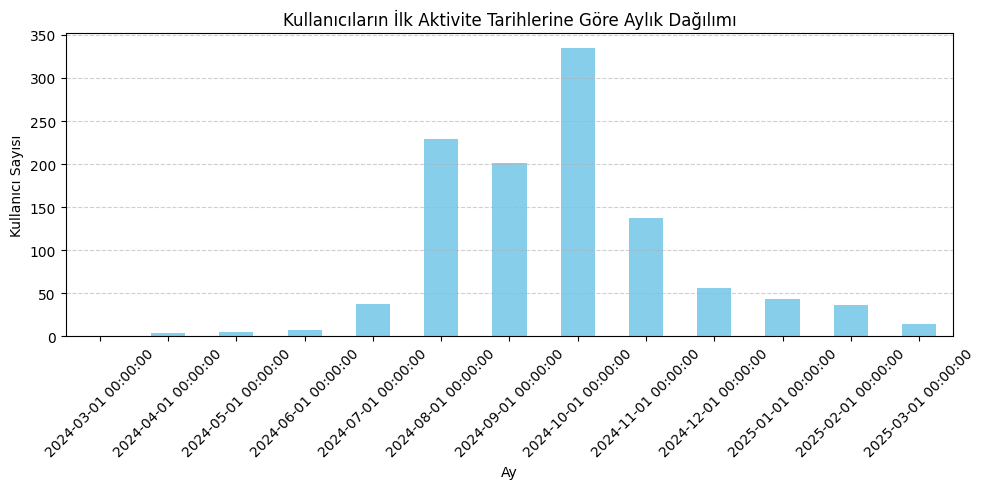

In [13]:
import matplotlib.pyplot as plt

# Aylık gruplama: kaç kullanıcı ilk kez o ay aktif olmuş
monthly_counts = model_df["first_activity"].dt.to_period("M").value_counts().sort_index()
monthly_counts.index = monthly_counts.index.to_timestamp()

# Barplot
plt.figure(figsize=(10, 5))
monthly_counts.plot(kind="bar", color="skyblue")
plt.title("Kullanıcıların İlk Aktivite Tarihlerine Göre Aylık Dağılımı")
plt.xlabel("Ay")
plt.ylabel("Kullanıcı Sayısı")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

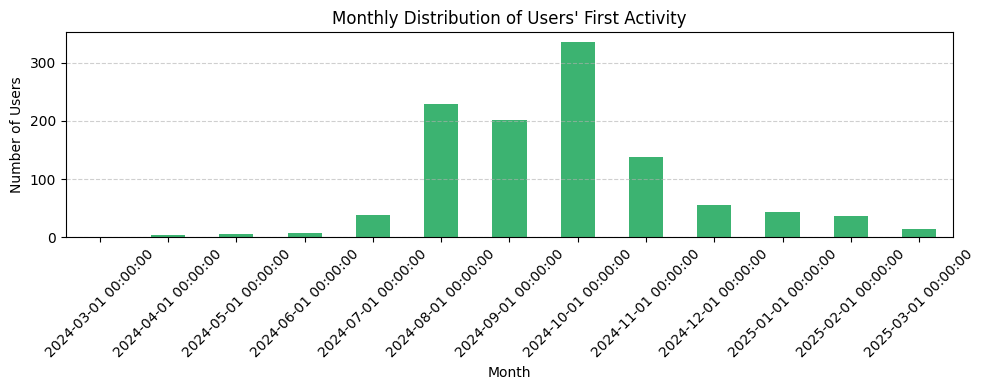

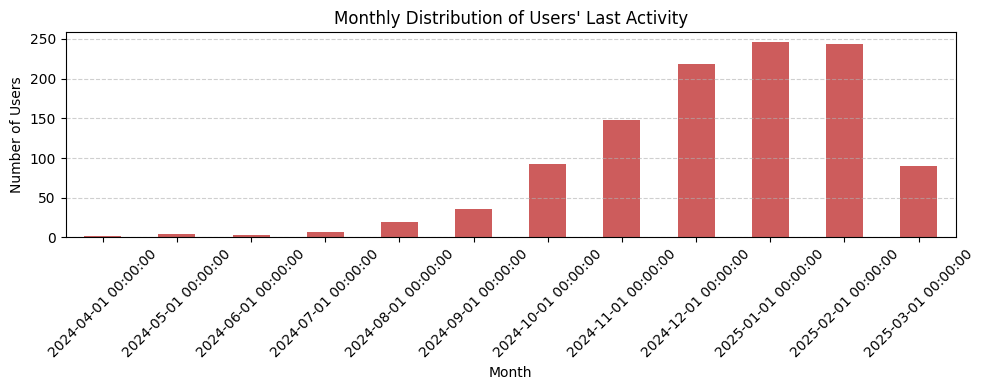

In [14]:
import matplotlib.pyplot as plt

# Ensure datetime type (optional safety check)
model_df["first_activity"] = pd.to_datetime(model_df["first_activity"])
model_df["last_activity"] = pd.to_datetime(model_df["last_activity"])

# First activity monthly counts
first_monthly = model_df["first_activity"].dt.to_period("M").value_counts().sort_index()
first_monthly.index = first_monthly.index.to_timestamp()

# Last activity monthly counts
last_monthly = model_df["last_activity"].dt.to_period("M").value_counts().sort_index()
last_monthly.index = last_monthly.index.to_timestamp()

# Plot First Activity
plt.figure(figsize=(10, 4))
first_monthly.plot(kind="bar", color="mediumseagreen")
plt.title("Monthly Distribution of Users' First Activity")
plt.xlabel("Month")
plt.ylabel("Number of Users")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# Plot Last Activity
plt.figure(figsize=(10, 4))
last_monthly.plot(kind="bar", color="indianred")
plt.title("Monthly Distribution of Users' Last Activity")
plt.xlabel("Month")
plt.ylabel("Number of Users")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [15]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings("ignore")

# Özellikleri ve hedefi seç
feature_cols = [
    "total_activities", "first_activity_ts", "active_weeks",
    "longest_streak_weeks", "avg_weekly_activity",
 "std_days_between_activities"
]
# "days_between_first_and_last"
X = model_df[feature_cols]
y = model_df["churn"]

# Eğitim/test bölmesi
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model oluştur ve eğit
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
model.fit(X_train, y_train)

# Tahmin yap
y_pred = model.predict(X_test)

# Performans metrikleri
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.75      0.79        61
           1       0.91      0.94      0.93       161

    accuracy                           0.89       222
   macro avg       0.87      0.85      0.86       222
weighted avg       0.89      0.89      0.89       222

Confusion Matrix:
[[ 46  15]
 [  9 152]]


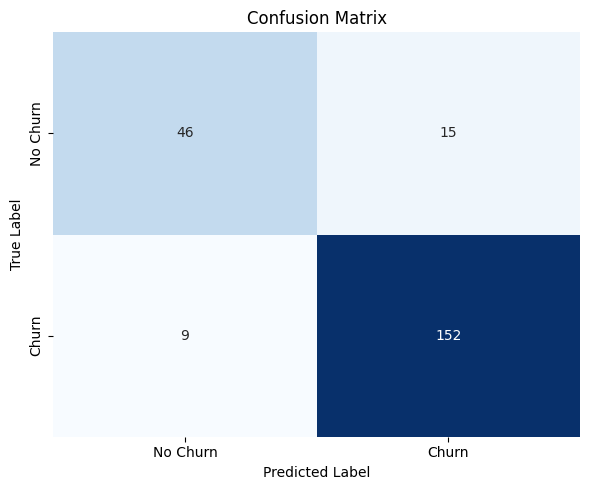

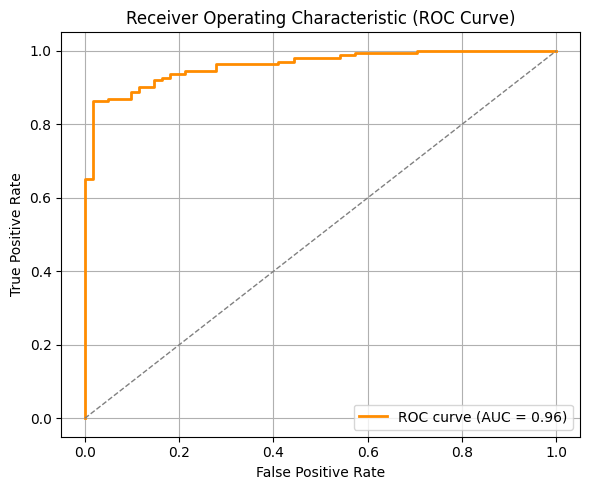

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# === 1. Confusion Matrix Plot ===
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# === 2. ROC Curve Plot ===
y_proba = model.predict_proba(X_test)[:, 1]  # Churn sınıfı için olasılıklar
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC Curve)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

In [17]:
display(shap_values)

.values =
array([[ -0.54611037,   3.7726744 ,  -0.0513854 , ...,   0.35280961,
         -4.13926543,   0.48357319],
       [ -1.14669289,  -1.50950169,  -0.05159064, ...,  -0.12097552,
          0.39057123,   0.75941609],
       [  0.99757479,  -3.17558328,   0.08466649, ...,  -0.70240232,
          3.04955833,  -0.51459514],
       ...,
       [ -0.94951916,   4.77033983,   0.10129064, ...,  -0.38918247,
          0.95818688,  -0.45937947],
       [  0.07045753, -11.41322353,   0.14593994, ...,  -0.52120483,
          3.27074359,   0.57581413],
       [  0.08061009,   3.97809407,   0.12956855, ...,   0.22271569,
          2.80105966,  -0.34020041]])

.base_values =
array([3.90023838, 3.90023838, 3.90023838, 3.90023838, 3.90023838,
       3.90023838, 3.90023838, 3.90023838, 3.90023838, 3.90023838,
       3.90023838, 3.90023838, 3.90023838, 3.90023838, 3.90023838,
       3.90023838, 3.90023838, 3.90023838, 3.90023838, 3.90023838,
       3.90023838, 3.90023838, 3.90023838, 3.90023838, 3.

📊 SHAP Özellik Önem Grafiği (Bar Plot)


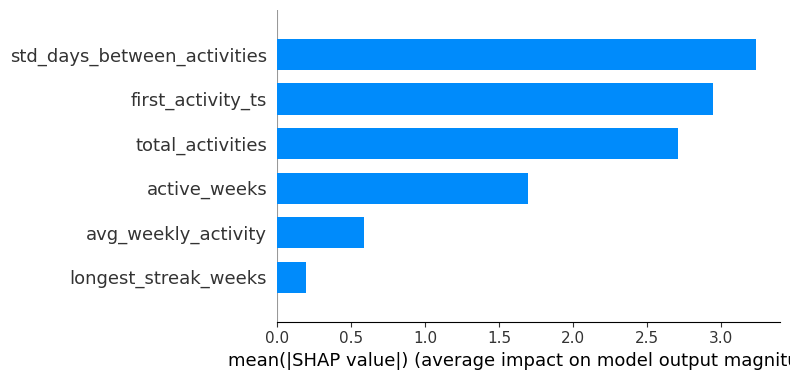

🔍 SHAP Etki Dağılımı (Renkli Nokta Grafiği)


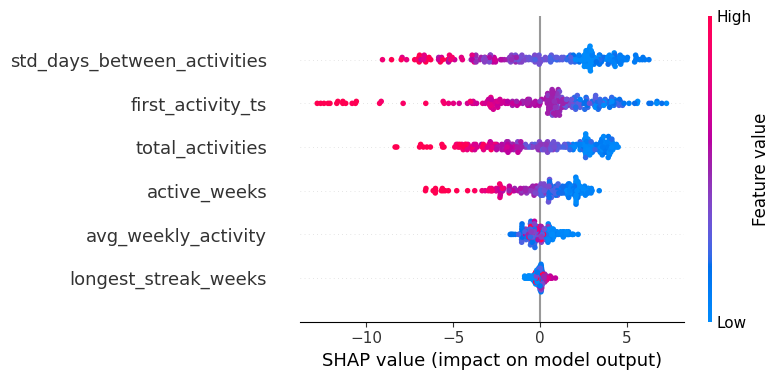

🧠 SHAP Force Plot – Öğrenci Bazında Açıklama


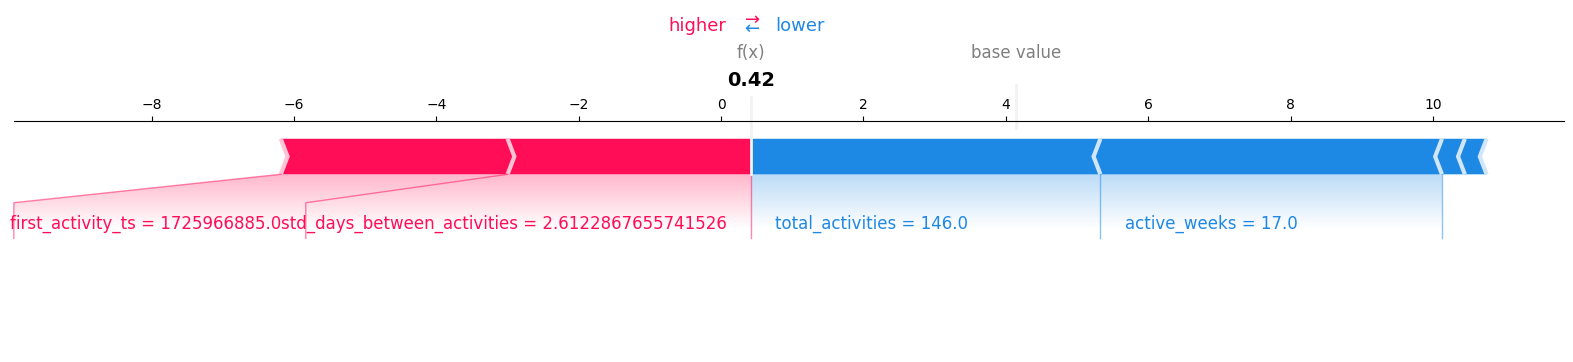

In [18]:
import shap
import matplotlib.pyplot as plt

# 1. SHAP explainer'ı oluştur
explainer = shap.Explainer(model, X_train)

# 2. SHAP değerlerini hesapla (additivity kontrolünü kapat)
shap_values = explainer(X_test, check_additivity=False)

# 3. Öznitelik önemini gösteren bar chart
print("📊 SHAP Özellik Önem Grafiği (Bar Plot)")
shap.summary_plot(shap_values, X_test, plot_type="bar")

# 4. Özellik değerlerinin etkisini gösteren dağılım grafiği
print("🔍 SHAP Etki Dağılımı (Renkli Nokta Grafiği)")
shap.summary_plot(shap_values, X_test)

# 5. Tek bir öğrencinin tahminine dair açıklama (örnek: ilk test örneği)
print("🧠 SHAP Force Plot – Öğrenci Bazında Açıklama")
shap.plots.force(shap_values[0], matplotlib=True)


📊 SHAP Feature Importance (Bar Plot)


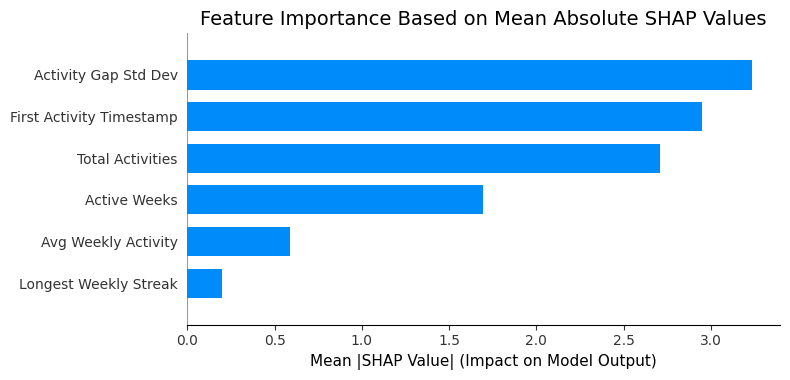

🔍 SHAP Feature Effects (Dot Plot)


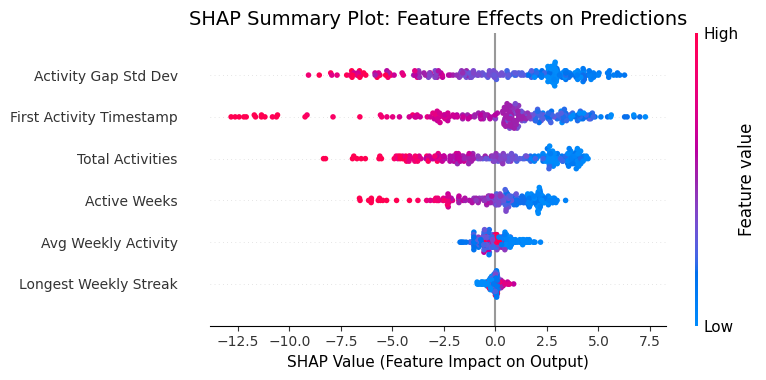

🧠 SHAP Force Plot – Single Prediction Explanation


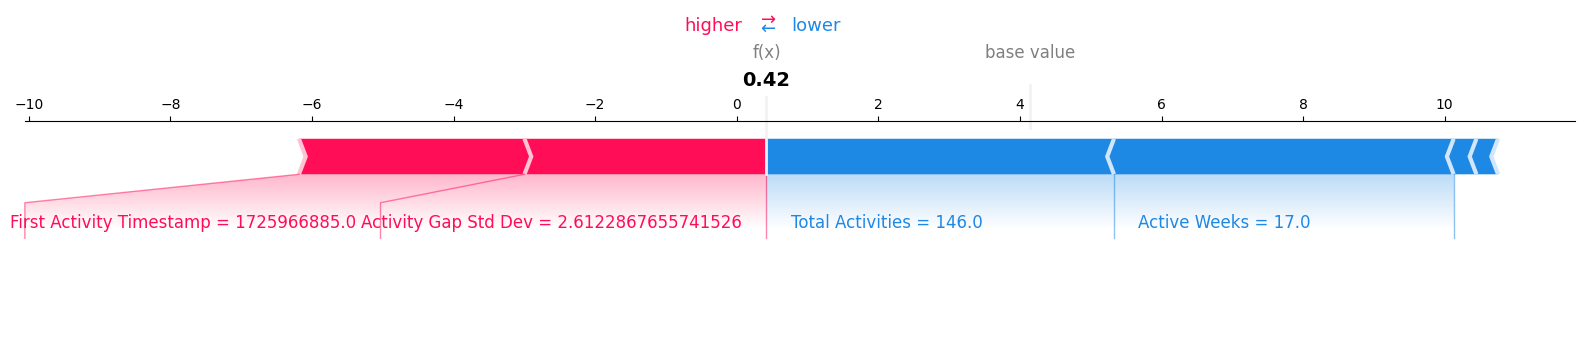

In [19]:
import shap
import matplotlib.pyplot as plt

# 1. Özelleştirilmiş isimler
rename_map = {
    "total_activities": "Total Activities",
    "avg_weekly_activity": "Avg Weekly Activity",
    "active_weeks": "Active Weeks",
    "longest_streak_weeks": "Longest Weekly Streak",
    "std_days_between_activities": "Activity Gap Std Dev",
    "days_since_last_activity": "Days Since Last Activity",
    "days_since_first_activity": "Days Since First Activity",
    "first_activity_ts": "First Activity Timestamp",
    "churn": "Churn"
}

# 2. Feature adlarını daha okunabilir hale getir
X_test_pretty = X_test.rename(columns=rename_map)

# 3. SHAP explainer
explainer = shap.Explainer(model, X_train)

# 4. SHAP değerleri
shap_values = explainer(X_test, check_additivity=False)
shap_values.feature_names = X_test_pretty.columns.tolist()

# 5. SHAP bar plot
print("📊 SHAP Feature Importance (Bar Plot)")
shap.summary_plot(shap_values, X_test_pretty, plot_type="bar", show=False)
plt.title("Feature Importance Based on Mean Absolute SHAP Values", fontsize=14)
plt.xlabel("Mean |SHAP Value| (Impact on Model Output)", fontsize=11)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

# 6. SHAP dot plot
print("🔍 SHAP Feature Effects (Dot Plot)")
shap.summary_plot(shap_values, X_test_pretty, show=False)
plt.title("SHAP Summary Plot: Feature Effects on Predictions", fontsize=14)
plt.xlabel("SHAP Value (Feature Impact on Output)", fontsize=11)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

# 7. Force plot
print("🧠 SHAP Force Plot – Single Prediction Explanation")
shap.plots.force(shap_values[0], matplotlib=True)